In [1]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
import cv2
import os
from tensorflow import keras
import glob as gb
import pandas as pd
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.layers import RandomFlip, RandomRotation
from tensorflow.keras.layers import Dense, Dropout, Flatten, Input
from tensorflow.keras.layers import Conv2D, MaxPool2D ,LeakyReLU
from sklearn.model_selection import train_test_split

In [2]:
IMG_SIZE = (224, 224) # resolution
directory = "Crop___Disease/Corn"
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.1  #   10% validation split
TEST_SPLIT = 0.1
num_class = 4
train_dataset = image_dataset_from_directory(directory,
                                             shuffle=True,
                                             labels='inferred',
                                             batch_size=BATCH_SIZE,
                                             image_size=IMG_SIZE,

                                             validation_split=VALIDATION_SPLIT + TEST_SPLIT,
                                             subset='training',
                                             color_mode='rgb',
                                             seed=42)
corn_validation_dataset = image_dataset_from_directory(directory,
                                             shuffle=True,
                                             labels='inferred',
                                             batch_size=BATCH_SIZE,
                                             image_size=IMG_SIZE,

                                             validation_split=VALIDATION_SPLIT + TEST_SPLIT,
                                             subset='validation',
                                             color_mode='rgb',
                                             seed=42)
# validation and test split proportions
num_val_samples = int((VALIDATION_SPLIT / (VALIDATION_SPLIT + TEST_SPLIT)) * corn_validation_dataset.cardinality().numpy())
validation_dataset = corn_validation_dataset.take(num_val_samples)
test_dataset = corn_validation_dataset.skip(num_val_samples)

print(f"Training dataset size: {len(train_dataset)} batches")
print(f"Validation dataset size: {len(validation_dataset)} batches")
print(f"Test dataset size: {len(test_dataset)} batches")

Found 14632 files belonging to 4 classes.
Using 11706 files for training.
Found 14632 files belonging to 4 classes.
Using 2926 files for validation.
Training dataset size: 366 batches
Validation dataset size: 46 batches
Test dataset size: 46 batches


In [3]:
class_names = train_dataset.class_names
class_names

['Corn___Common_Rust',
 'Corn___Gray_Leaf_Spot',
 'Corn___Healthy',
 'Corn___Leaf_Blight']

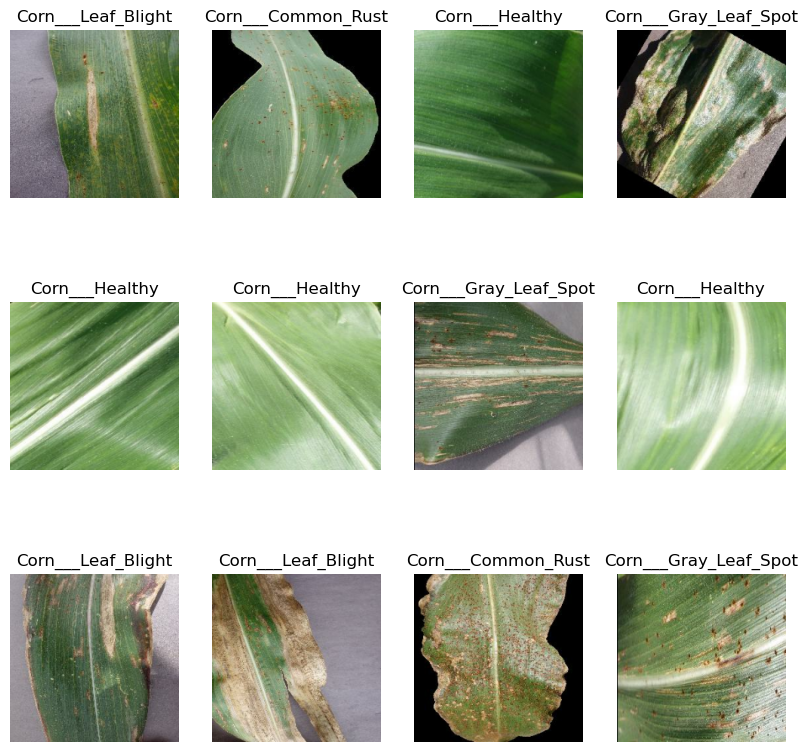

In [4]:
plt.figure(figsize=(10, 10))
for image_batch, labels_batch in train_dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")

C:\Users\NAHID\AppData\Local\Temp\ipykernel_14220\2436110488.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=folder_names, y=Data_imbalance, palette="rocket")


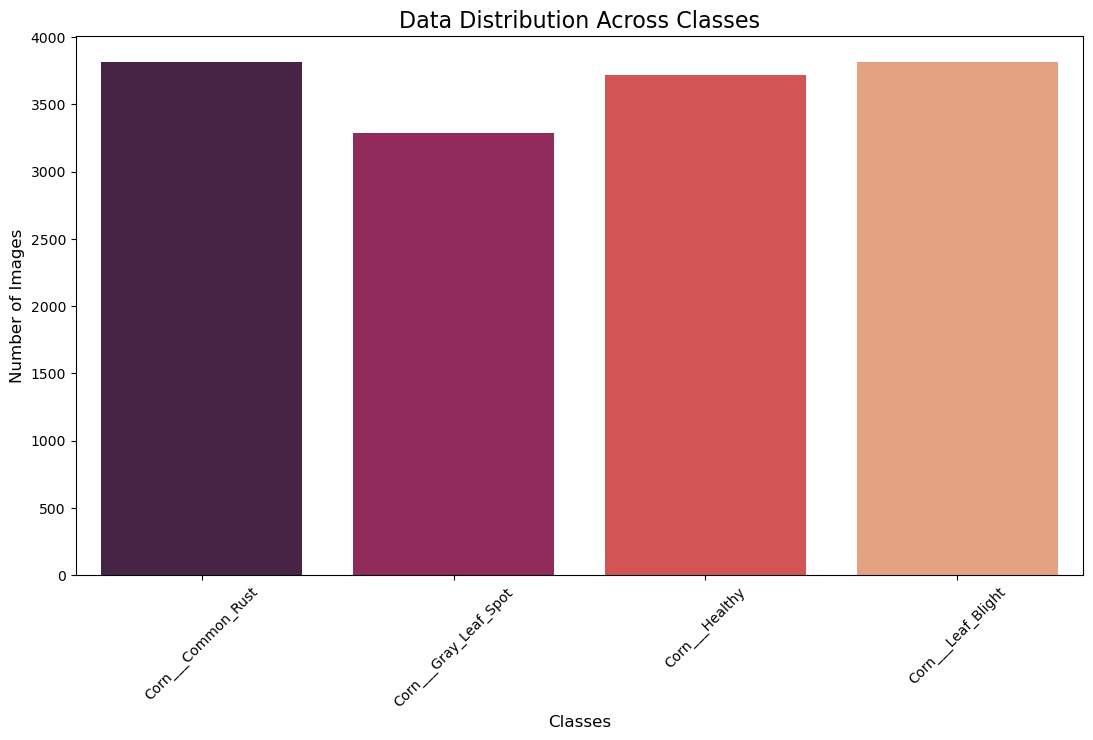

In [5]:
Data_imbalance = []
folder_names = []

# Iterate through each folder in the directory
for folder in os.listdir(directory):
    folder_path = os.path.join(directory, folder)
    if os.path.isdir(folder_path):  # Ensure it's a folder
        files = gb.glob(pathname=str(folder_path + "/*.*"))
        Data_imbalance.append(len(files))
        folder_names.append(folder)  # Collect folder names dynamically

# Plot the barplot with dynamic names
plt.figure(figsize=(13, 7))
sns.barplot(x=folder_names, y=Data_imbalance, palette="rocket")
plt.title("Data Distribution Across Classes", fontsize=16)
plt.xlabel("Classes", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.xticks(rotation=45)  # Rotate x-axis labels if they are long
plt.show()

In [6]:
total = 0
for i in range(0,len(Data_imbalance)) :
    total +=Data_imbalance[i]

weight_for_0 = (1 / Data_imbalance[0]) * (total / 4.0)
weight_for_1 = (1 / Data_imbalance[1]) * (total / 4.0)
weight_for_2 = (1 / Data_imbalance[2]) * (total / 4.0)
weight_for_3 = (1 / Data_imbalance[3]) * (total / 4.0)

class_weight = {0: weight_for_0, 1: weight_for_1, 2: weight_for_2, 3: weight_for_3}

print('Weight for class 0: {:.2f}'.format(weight_for_0))
print('Weight for class 1: {:.2f}'.format(weight_for_1))
print('Weight for class 2: {:.2f}'.format(weight_for_2))
print('Weight for class 3: {:.2f}'.format(weight_for_3))

Weight for class 0: 0.96
Weight for class 1: 1.11
Weight for class 2: 0.98
Weight for class 3: 0.96


In [7]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2, fill_mode='reflect'),
    tf.keras.layers.RandomZoom(0.2, fill_mode='reflect'),
    tf.keras.layers.RandomHeight(0.2),
    tf.keras.layers.RandomWidth(0.2)
])

In [8]:
import logging

# Set the logging level to suppress warnings
logging.getLogger('tensorflow').setLevel(logging.ERROR)

In [9]:
# Define mean and std for normalization
mean = tf.constant([0.485, 0.456, 0.406])  # ImageNet mean for R, G, B
std = tf.constant([0.229, 0.224, 0.225])   # ImageNet std for R, G, B

# Function to normalize after rescaling
def normalize_image(image, label):
    # Rescale image to [0, 1]
    image = tf.cast(image, tf.float32) / 255.0
    # Normalize image
    image = (image - mean) / std
    return image, label

# Apply normalization to the augmented dataset
train_dataset = train_dataset.map(normalize_image, num_parallel_calls=tf.data.AUTOTUNE)
validation_dataset = validation_dataset.map(normalize_image, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_dataset.map(normalize_image, num_parallel_calls=tf.data.AUTOTUNE)

In [10]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from vit_keras import vit
import kagglehub
import tensorflow_hub as hub
from tensorflow.keras.layers import Input, Dense, Dropout, Concatenate

# Define SAM training step with tunable rho
def train_step_sam(model, data, rho=0.05):
    if len(data) == 3:
        x, y, sample_weight = data
    else:
        x, y = data
        sample_weight = None

    # First forward-backward pass
    with tf.GradientTape() as tape:
        y_pred = model(x, training=True)
        loss = model.compiled_loss(y, y_pred, 
                                 sample_weight=sample_weight,
                                 regularization_losses=model.losses)
    
    trainable_vars = model.trainable_variables
    gradients = tape.gradient(loss, trainable_vars)
    
    # Calculate perturbation
    grad_norm = tf.linalg.global_norm(gradients)
    eps_w = [tf.math.multiply(g, rho / grad_norm) for g in gradients]
    
    # Apply perturbation
    for var, eps in zip(trainable_vars, eps_w):
        var.assign_add(eps)
    
    # Second forward-backward pass
    with tf.GradientTape() as tape:
        y_pred = model(x, training=True)
        loss = model.compiled_loss(y, y_pred,
                                 sample_weight=sample_weight,
                                 regularization_losses=model.losses)
    
    gradients = tape.gradient(loss, trainable_vars)
    
    # Remove perturbation and apply gradients
    for var, eps in zip(trainable_vars, eps_w):
        var.assign_sub(eps)
    
    model.optimizer.apply_gradients(zip(gradients, trainable_vars))
    
    # Update metrics
    model.compiled_metrics.update_state(y, y_pred, sample_weight=sample_weight)
    return {m.name: m.result() for m in model.metrics}

# Define custom hybrid model with SAM
class HybridViTSwinModel(tf.keras.Model):
    def __init__(self, vit_base, swin_base, data_augmentation, num_classes, rho, 
                 dense_units, dropout_rate, learning_rate):
        super(HybridViTSwinModel, self).__init__(name='HybridViTSwin')
        self.data_augmentation = data_augmentation
        self.resizing = layers.Resizing(224, 224)
        self.vit_base = vit_base
        self.swin_base = swin_base
        self.dense_vit = Dense(dense_units, activation='relu')
        self.dropout_vit = Dropout(dropout_rate)
        self.dropout_swin = Dropout(dropout_rate)
        self.dense_swin = Dense(dense_units, activation='gelu')
        self.concat = Concatenate()
        self.dropout_combined = Dropout(dropout_rate)
        self.classifier = Dense(num_classes, activation='softmax')
        self.rho = rho
        self.learning_rate = learning_rate

    def call(self, inputs):
        x = self.data_augmentation(inputs)
        x = self.resizing(x)
        
        # ViT branch
        vit_features = self.vit_base(x)
        vit_features = self.dense_vit(vit_features)
        vit_features = self.dropout_vit(vit_features)
        
        # Swin branch
        swin_features = self.swin_base(x, training=True)
        swin_features = self.dropout_swin(swin_features)
        swin_features = self.dense_swin(swin_features)
        
        # Combine features
        combined = self.concat([vit_features, swin_features])
        combined = self.dropout_combined(combined)
        
        return self.classifier(combined)

    def train_step(self, data):
        return train_step_sam(self, data, rho=self.rho)

# Define the model building function for Keras Tuner
def build_model(hp):
    # Define hyperparameters to tune
    rho = hp.Float('rho', min_value=0.01, max_value=0.1, step=0.01)
    dense_units = hp.Int('dense_units', min_value=64, max_value=256, step=64)
    dropout_rate = hp.Float('dropout_rate', min_value=0.3, max_value=0.7, step=0.1)
    learning_rate = hp.Choice('learning_rate', values=[1e-4, 5e-4, 1e-3, 5e-3])
    
    # Create ViT base model (frozen)
    vit_base = vit.vit_b16(
        image_size=IMG_SIZE,
        activation='softmax',
        pretrained=True,
        include_top=False,
        pretrained_top=False,
        classes=num_class
    )
    vit_base.trainable = False
    
    # Create Swin base model (frozen)
    swin_path = kagglehub.model_download("spsayakpaul/swin/tensorFlow2/tiny-patch4-window7-224")
    swin_base = hub.KerasLayer(swin_path, trainable=False)
    
    model = HybridViTSwinModel(
        vit_base, 
        swin_base, 
        data_augmentation, 
        num_class, 
        rho, 
        dense_units, 
        dropout_rate, 
        learning_rate
    )
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy']
    )
    return model

# Instantiate the tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=1,
    directory='hybrid_tuning',
    project_name='vit_swin_sam_tuning'
)

# Display search space summary
tuner.search_space_summary()

# Perform the hyperparameter search
tuner.search(
    train_dataset,
    validation_data=validation_dataset,
    epochs=5,
    class_weight=class_weight
)

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best rho: {best_hps.get('rho')}")
print(f"Best dense_units: {best_hps.get('dense_units')}")
print(f"Best dropout_rate: {best_hps.get('dropout_rate')}")
print(f"Best learning_rate: {best_hps.get('learning_rate')}")

# Build the model with the best hyperparameters
best_model = tuner.hypermodel.build(best_hps)

# Train the best model
print("\nTraining best hybrid model...")
hybrid_history = best_model.fit(
    train_dataset,
    class_weight=class_weight,
    validation_data=validation_dataset,
    epochs=10
)


Trial 5 Complete [00h 28m 55s]
val_accuracy: 0.95652174949646

Best val_accuracy So Far: 0.979619562625885
Total elapsed time: 02h 23m 08s
Best rho: 0.08
Best dense_units: 128
Best dropout_rate: 0.5
Best learning_rate: 0.0005

Training best hybrid model...
Epoch 1/10
366/366 [==============================] - 378s 938ms/step - loss: 0.3801 - accuracy: 0.8590 - val_loss: 0.0887 - val_accuracy: 0.9742
Epoch 2/10
366/366 [==============================] - 340s 927ms/step - loss: 0.1644 - accuracy: 0.9358 - val_loss: 0.0948 - val_accuracy: 0.9701
Epoch 3/10
366/366 [==============================] - 334s 913ms/step - loss: 0.1342 - accuracy: 0.9467 - val_loss: 0.0712 - val_accuracy: 0.9769
Epoch 4/10
366/366 [==============================] - 334s 912ms/step - loss: 0.1233 - accuracy: 0.9518 - val_loss: 0.0782 - val_accuracy: 0.9715
Epoch 5/10
366/366 [==============================] - 330s 902ms/step - loss: 0.1043 - accuracy: 0.9569 - val_loss: 0.0701 - val_accuracy: 0.9810
Epoch 6/10
36

In [11]:
# Display model summary
print("\nHybrid ViT-Swin Model Summary:")
best_model.summary()


Hybrid ViT-Swin Model Summary:
Model: "HybridViTSwin"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (None, None, None, 3)     0         
                                                                 
 resizing_1 (Resizing)       multiple                  0         
                                                                 
 vit-b16 (Functional)        (None, 768)               85798656  
                                                                 
 keras_layer_1 (KerasLayer)  multiple                  28288354  
                                                                 
 dense_3 (Dense)             multiple                  98432     
                                                                 
 dropout_3 (Dropout)         multiple                  0         
                                                                 
 dropout_4 (Dropout) 

In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
print(f"Test dataset type: {type(test_dataset)}") 

for image, label in test_dataset.take(1):
    print(f"Sample image shape: {image.shape}, Sample label shape: {label.shape}")

# Initialize empty lists to store true labels and predicted labels
y_true = []
y_pred_classes = []

# Iterate through the test dataset to collect the true labels and predictions
for images, labels in test_dataset:
    # Collect true labels (convert to numpy array)
    y_true.extend(labels.numpy())
    
    # Make predictions using the model
    y_pred_prob = best_model(images, training=False)  # Model predictions (probabilities)
    
    # Convert predicted probabilities to class labels (argmax along the class axis)
    y_pred_classes.extend(tf.argmax(y_pred_prob, axis=1).numpy())

# Convert y_true and y_pred_classes to NumPy arrays for compatibility with sklearn
y_true = np.array(y_true)
y_pred_classes = np.array(y_pred_classes)

# Ensure the shape of the true and predicted labels are consistent
print(f"Shape of y_true: {y_true.shape}")
print(f"Shape of y_pred_classes: {y_pred_classes.shape}")

# Now, you can compute the precision, recall, and f1-score
precision = precision_score(y_true, y_pred_classes, average='weighted')
recall = recall_score(y_true, y_pred_classes, average='weighted')
f1 = f1_score(y_true, y_pred_classes, average='weighted')

# Evaluate the model on the test dataset
test_loss, test_accuracy = best_model.evaluate(test_dataset)

# Print the results
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")

Test dataset type: <class 'tensorflow.python.data.ops.dataset_ops.ParallelMapDataset'>
Sample image shape: (32, 224, 224, 3), Sample label shape: (32,)
Shape of y_true: (1454,)
Shape of y_pred_classes: (1454,)
46/46 [==============================] - 15s 301ms/step - loss: 0.0852 - accuracy: 0.9622
Test Loss: 0.08515385538339615
Test Accuracy: 0.962173342704773
Precision: 0.9657440020272628
Recall: 0.9614855570839065
F1-Score: 0.9614144637353996


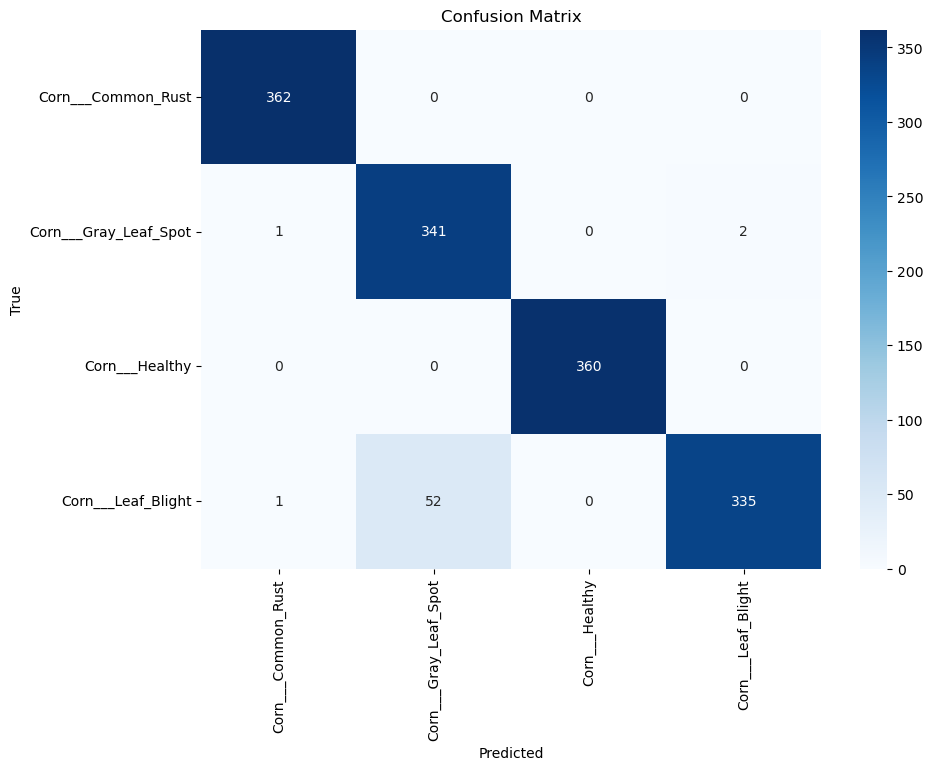

In [13]:
from sklearn.metrics import confusion_matrix
# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

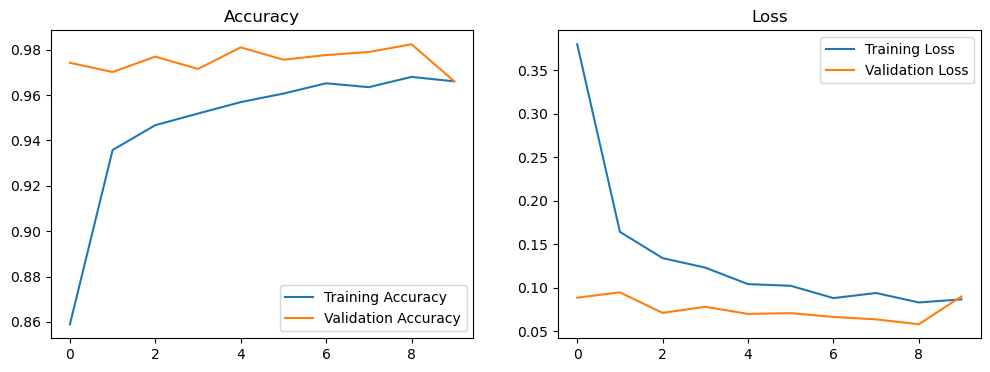

In [14]:
#Graph
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(hybrid_history.history['accuracy'], label='Training Accuracy')
plt.plot(hybrid_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hybrid_history.history['loss'], label='Training Loss')
plt.plot(hybrid_history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()

plt.show()

In [15]:
best_model.save("corn_vit_swin_hybrid_model", save_format="tf")